In [2]:
#数据导入及处理缺失值
#Data import and handling of missing values
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 加载数据
# load data
data = fetch_california_housing()

X = data.data          # 特征值eigenvalue
y = data.target        # 目标值（房价）Target value (house price)

feature_names = data.feature_names

# Transfer to DataFrame（推荐，方便后续操作）
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="MedHouseVal")

print(X.head())
print(y.head())
print("Shape of X:", X.shape)

# ===== 处理缺失值 =====
#Handling Missing Values
print("Missing values before cleaning:")
print(X.isnull().sum())

# 删除含缺失值的行（如果有）
# Delete rows with missing values (if any).
X = X.dropna()
y = y.loc[X.index]   # 保持 X 和 y 对齐 Align X and Y

print("Shape after removing missing values:", X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)


In [3]:
#Baseline Modal
#Data preprocessing and division of training，validation and test set
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 先从X特征值，y房价 中分出 test 和 train_val两个数据集
# First, separate the "X feature values" and "y house prices" into two datasets: "test" and "train_val".
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)
# X_train_val → 80% 的特征，X_test → 20% 的特征，y_train_val → 80% 的标签，y_test → 20% 的标签
# X_train_val → 80% of the features, X_test → 20% of the features, 
# y_train_val → 80% of the labels, y_test → 20% of the labels

# 从X_train_val, y_train_val里再分 validation（分成X_train, X_val, y_train, y_val）
# From X_train_val and y_train_val, further divide into validation (resulting in X_train, X_val, y_train, y_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)#这里的0.1是train_val80%里的10%
#Here, 0.1 refers to the 10% within the "train_val 80%" portion.


# 在标准化前，先保存 raw（未标准化）版本：后面kNN需要用原始经纬度
# Before standardization, save the raw (unstandardized) version first: 
# the kNN algorithm later will require the original latitude and longitude values.
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

# scale (fit only on train) and then convert it back to a DataFrame#标准化（只在训练集）并转回DataFrame
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns,index=X_train_raw.index)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X.columns,index=X_val_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test_raw.index)
#scaler.transform 标准化 test 数据 means to Standardized test data
#index=X_test_raw.index Pandas 会默认生成新的 0~n 索引 Pandas will automatically generate new indices ranging from 0 to n.
#Add index=...，这样索引不会乱（对齐 y / 后面 debug 更稳）so the index won't be disordered (it will be more stable when aligning y / and then the debug part).

Architecture: (32,), Activation: tanh, Validation MSE: 0.3137
Architecture: (32,), Activation: relu, Validation MSE: 0.3262
Architecture: (32,), Activation: logistic, Validation MSE: 0.3210
Architecture: (64,), Activation: tanh, Validation MSE: 0.3140
Architecture: (64,), Activation: relu, Validation MSE: 0.3272
Architecture: (64,), Activation: logistic, Validation MSE: 0.3120
Architecture: (64, 32), Activation: tanh, Validation MSE: 0.2841
Architecture: (64, 32), Activation: relu, Validation MSE: 0.2890
Architecture: (64, 32), Activation: logistic, Validation MSE: 0.3078


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Architecture: (128, 32), Activation: tanh, Validation MSE: 0.2891
Architecture: (128, 32), Activation: relu, Validation MSE: 0.2796


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Architecture: (128, 32), Activation: logistic, Validation MSE: 0.2935
Architecture: (128, 64), Activation: tanh, Validation MSE: 0.2798
Architecture: (128, 64), Activation: relu, Validation MSE: 0.2793
Architecture: (128, 64), Activation: logistic, Validation MSE: 0.2855
Architecture: (128, 64, 32), Activation: tanh, Validation MSE: 0.3134
Architecture: (128, 64, 32), Activation: relu, Validation MSE: 0.2987
Architecture: (128, 64, 32), Activation: logistic, Validation MSE: 0.2941

=== Validation MSE Table ===
Activation     logistic      relu      tanh
Architecture                               
(32,)          0.320968  0.326200  0.313691
(64,)          0.312038  0.327152  0.313980
(64, 32)       0.307780  0.289044  0.284061
(128, 32)      0.293450  0.279552  0.289105
(128, 64)      0.285536  0.279279  0.279801
(128, 64, 32)  0.294129  0.298666  0.313435


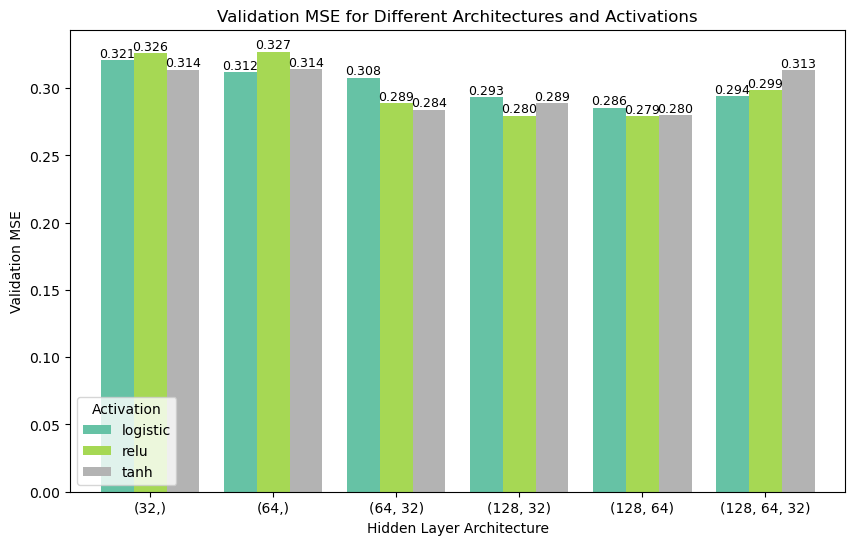

In [ ]:
#寻找最优隐藏层与激活函数
#Search for the optimal hidden layer and activation function
import matplotlib.pyplot as plt
# 1) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================

# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32,),
    (64,),
    (64,32),
    (128,32),
    (128,64),
    (128,64,32)
]

# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
#
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数

activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 2) Train models and collect Test MSE
# 训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        #
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model_test_act = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=800,
            early_stopping=False,
            random_state=26
        )

        
        # Train the model on the training dataset.
        # 在训练集上训练模型

        model_test_act.fit(X_train, y_train)

        
        # Predict house prices on the validation set
        # 在验证集上进行预测

        val_pred_act = model_test_act.predict(X_val)

        # Compute Mean Squared Error (MSE) on validation set
        # 计算验证集上的均方误差

        val_mse_act = mean_squared_error(y_val, val_pred_act)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Validation_MSE': val_mse_act
        })

        print(f"Architecture: {arch}, Activation: {act}, Validation MSE: {val_mse_act:.4f}")

# ============================================================
# 3) Convert results to DataFrame
# 将结果转换为表格
# ============================================================

# 
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
#

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Validation_MSE'
)

# -------------------------------------------------
# Arrange the architecture according to the complexity of the hidden layers
# 按隐藏层的复杂程度进行排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 32)','(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Validation MSE Table ===")
print(pivot_table)


# ============================================================
# 4) Plot grouped bar chart
#  绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Validation MSE for each
# architecture and activation combination.
#

# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Validation MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Validation MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Validation MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------

  
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()# 获取柱子的高度（MSE值）Get bar height (MSE value)
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()


In [4]:
#这个代码块还没修改好，最终预测可能把val和train合起来一起train？
'''
# 重新fit scaler：这次用整个 train_val
scaler_final = StandardScaler()
X_train_val_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_val),
    columns=X.columns,
    index=X_train_val.index
)
X_test_scaled = pd.DataFrame(
    scaler_final.transform(X_test),
    columns=X.columns,
    index=X_test.index
)
'''
# model (no internal early stopping, since you already have X_val)
model = MLPRegressor(
    hidden_layer_sizes=(128,32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

model.fit(X_train, y_train)
'''
model.fit(X_train_val_scaled, y_train_val)

test_pred = model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, test_pred)

print("Final Test MSE:", test_mse)
'''
#测试集和预测集的预测
#The predictions of the test set and the prediction set
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# 训练集预测
#Training set prediction
train_pred = model.predict(X_train)
# 计算训练误差
# Calculate training error
train_mse = mean_squared_error(y_train, train_pred)

print("Baseline Train MSE:", train_mse)#加入是为了判断是不是欠拟合或者过拟合Joining is to determine whether it is underfitting or overfitting.
print("Validation MSE:", mean_squared_error(y_val, val_pred))#Mean Squared Error（均方误差）
print("Test MSE:", mean_squared_error(y_test, test_pred))

Baseline Train MSE: 0.2234611522537491
Validation MSE: 0.2788722368528112
Test MSE: 0.25035955553731826


In [8]:
#luke的代码块

In [17]:
# ============================================================
# Model 2: Add neighbourhood-based features
# 第二个模型：加入基于邻居房价的特征
# ============================================================

from sklearn.neighbors import NearestNeighbors

K = 7  # Number of nearest neighbours used to construct neighbourhood features
       # 用于构造 neighbourhood 特征的邻居数量


# ------------------------------------------------------------
# 1) Fit kNN using training coordinates only
#    This ensures neighbourhood features are constructed
#    solely from training data and avoids data leakage.
#
# 1）仅使用训练集经纬度建立 kNN
#    这样 neighbourhood 特征只依赖训练集数据，避免数据泄露
# ------------------------------------------------------------
knn = NearestNeighbors(n_neighbors=K + 1)
knn.fit(X_train_raw[['Latitude', 'Longitude']])

# Align y_train with X_train_raw so neighbour indices correctly map to prices
# 保证 y_train 与 X_train_raw 行顺序完全一致，从而邻居索引能正确对应房价
y_train_aligned = y_train.loc[X_train_raw.index].to_numpy()


# ------------------------------------------------------------
# 2) Define a function to compute neighbourhood price statistics
#    Supported summaries: mean / median / min / max / range
#
# 2）定义函数：计算邻居房价的统计特征
#    支持的统计量包括：mean / median / min / max / range
# ------------------------------------------------------------
def neighbour_summary_feature(query_df, summary="mean", exclude_self=False):
    """
    Compute a neighbourhood-based price summary for each sample.

    为每个样本计算基于邻居房价的统计特征

    Parameters / 参数
    ----------
    query_df : DataFrame
        Dataset for which the feature is computed
        需要构造 neighbourhood 特征的数据集

    summary : str
        One of: "mean", "median", "min", "max", "range"
        统计方式：均值 / 中位数 / 最小值 / 最大值 / 极差

    exclude_self : bool
        Whether to remove the sample itself from neighbours
        如果 query_df 是训练集本身，是否移除自身这个邻居

    Returns / 返回
    -------
    np.ndarray
        Neighbourhood summary feature for each sample
        每个样本对应的 neighbourhood 特征值
    """

    # Find nearest neighbours based on geographic coordinates
    # 基于经纬度寻找最近邻样本
    _, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

    values = []

    # Loop through each sample and compute the summary statistic
    # 遍历每个样本，并计算邻居房价的统计量
    for row_i, idxs in enumerate(inds):

        if exclude_self:
            # Remove the sample itself if it appears in neighbours
            # 如果邻居列表中包含自己，则将其移除
            idxs = idxs[idxs != row_i]

            # Keep exactly K neighbours
            # 保证最终保留 K 个邻居
            idxs = idxs[:K]

        else:
            # Validation/test samples are not part of training set
            # so we directly take the first K neighbours
            # 验证集和测试集不在训练集中，因此直接取前 K 个邻居
            idxs = idxs[:K]

        # Retrieve neighbour prices
        # 获取这些邻居对应的房价
        neigh_prices = y_train_aligned[idxs]

        if summary == "mean":
            values.append(np.mean(neigh_prices))

        elif summary == "median":
            values.append(np.median(neigh_prices))

        elif summary == "min":
            values.append(np.min(neigh_prices))

        elif summary == "max":
            values.append(np.max(neigh_prices))

        elif summary == "range":
            # Range = max − min
            # 极差 = 最大值 − 最小值
            values.append(np.max(neigh_prices) - np.min(neigh_prices))

        else:
            raise ValueError("summary must be one of: mean, median, min, max, range")

    return np.array(values)


# ------------------------------------------------------------
# 3) Compute five neighbourhood-based features
# 3）计算五种 neighbourhood 特征
# ------------------------------------------------------------

# Neighbourhood mean price / 邻域平均房价
neigh_price_mean_train = neighbour_summary_feature(X_train_raw, summary="mean", exclude_self=True)
neigh_price_mean_val   = neighbour_summary_feature(X_val_raw, summary="mean", exclude_self=False)
neigh_price_mean_test  = neighbour_summary_feature(X_test_raw, summary="mean", exclude_self=False)

# Neighbourhood median price / 邻域房价中位数
neigh_price_median_train = neighbour_summary_feature(X_train_raw, summary="median", exclude_self=True)
neigh_price_median_val   = neighbour_summary_feature(X_val_raw, summary="median", exclude_self=False)
neigh_price_median_test  = neighbour_summary_feature(X_test_raw, summary="median", exclude_self=False)

# Neighbourhood minimum price / 邻域最低房价
neigh_price_min_train = neighbour_summary_feature(X_train_raw, summary="min", exclude_self=True)
neigh_price_min_val   = neighbour_summary_feature(X_val_raw, summary="min", exclude_self=False)
neigh_price_min_test  = neighbour_summary_feature(X_test_raw, summary="min", exclude_self=False)

# Neighbourhood maximum price / 邻域最高房价
neigh_price_max_train = neighbour_summary_feature(X_train_raw, summary="max", exclude_self=True)
neigh_price_max_val   = neighbour_summary_feature(X_val_raw, summary="max", exclude_self=False)
neigh_price_max_test  = neighbour_summary_feature(X_test_raw, summary="max", exclude_self=False)

# Neighbourhood price range / 邻域房价极差
neigh_price_range_train = neighbour_summary_feature(X_train_raw, summary="range", exclude_self=True)
neigh_price_range_val   = neighbour_summary_feature(X_val_raw, summary="range", exclude_self=False)
neigh_price_range_test  = neighbour_summary_feature(X_test_raw, summary="range", exclude_self=False)


# ------------------------------------------------------------
# 4) Add new neighbourhood features to the raw datasets
# 4）将新的 neighbourhood 特征加入原始数据
# ------------------------------------------------------------
X_train_enh_raw = X_train_raw.copy()
X_val_enh_raw   = X_val_raw.copy()
X_test_enh_raw  = X_test_raw.copy()

X_train_enh_raw['NeighbourPriceMean'] = neigh_price_mean_train
X_val_enh_raw['NeighbourPriceMean']   = neigh_price_mean_val
X_test_enh_raw['NeighbourPriceMean']  = neigh_price_mean_test

X_train_enh_raw['NeighbourPriceMedian'] = neigh_price_median_train
X_val_enh_raw['NeighbourPriceMedian']   = neigh_price_median_val
X_test_enh_raw['NeighbourPriceMedian']  = neigh_price_median_test

X_train_enh_raw['NeighbourPriceMin'] = neigh_price_min_train
X_val_enh_raw['NeighbourPriceMin']   = neigh_price_min_val
X_test_enh_raw['NeighbourPriceMin']  = neigh_price_min_test

X_train_enh_raw['NeighbourPriceMax'] = neigh_price_max_train
X_val_enh_raw['NeighbourPriceMax']   = neigh_price_max_val
X_test_enh_raw['NeighbourPriceMax']  = neigh_price_max_test

X_train_enh_raw['NeighbourPriceRange'] = neigh_price_range_train
X_val_enh_raw['NeighbourPriceRange']   = neigh_price_range_val
X_test_enh_raw['NeighbourPriceRange']  = neigh_price_range_test


# ------------------------------------------------------------
# 5) Standardise the enhanced dataset
#    Fit scaler only on the training set to avoid data leakage
#
# 5）对增强后的数据进行标准化
#    只在训练集上拟合 scaler，避免数据泄露
# ------------------------------------------------------------
scaler2 = StandardScaler()

X_train_enh = pd.DataFrame(
    scaler2.fit_transform(X_train_enh_raw),
    columns=X_train_enh_raw.columns,
    index=X_train_enh_raw.index
)

X_val_enh = pd.DataFrame(
    scaler2.transform(X_val_enh_raw),
    columns=X_val_enh_raw.columns,
    index=X_val_enh_raw.index
)

X_test_enh = pd.DataFrame(
    scaler2.transform(X_test_enh_raw),
    columns=X_test_enh_raw.columns,
    index=X_test_enh_raw.index
)


# ------------------------------------------------------------
# 6) Train the enhanced model
#    Keep the same hyperparameters as the baseline model
#    for a fair comparison
#
# 6）训练增强后的模型
#    超参数尽量与 baseline 保持一致，保证对比公平
# ------------------------------------------------------------
model_enh = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

model_enh.fit(X_train_enh, y_train)


# ------------------------------------------------------------
# 7) Evaluate the enhanced model
# 7）评估增强后的模型性能
# ------------------------------------------------------------
train_pred_enh = model_enh.predict(X_train_enh)
val_pred_enh   = model_enh.predict(X_val_enh)
test_pred_enh  = model_enh.predict(X_test_enh)

enh_train_mse = mean_squared_error(y_train, train_pred_enh)
enh_val_mse   = mean_squared_error(y_val, val_pred_enh)
enh_test_mse  = mean_squared_error(y_test, test_pred_enh)

print("Enhanced Train MSE:", enh_train_mse)
print("Enhanced Validation MSE:", enh_val_mse)
print("Enhanced Test MSE:", enh_test_mse)


# ------------------------------------------------------------
# 8) Compare with baseline model
# 8）与 baseline 模型进行比较
# ------------------------------------------------------------
baseline_val_mse = mean_squared_error(y_val, val_pred)

print("Delta Validation MSE (Enhanced - Baseline):", enh_val_mse - baseline_val_mse)

Enhanced Train MSE: 0.1430487816511552
Enhanced Validation MSE: 0.23298984722872768
Enhanced Test MSE: 0.17961011645948402
Delta Validation MSE (Enhanced - Baseline): -0.04588238962408353


In [18]:
# ============================================================
# Compare five single neighbourhood-based features
# Each experiment adds only one additional feature
# to the baseline model for comparison
#
# 对五种 neighbourhood 特征分别进行单独比较
# 每次实验只在 baseline 模型基础上加入一个新特征
# ============================================================


def run_extra_feature(feature_name, f_train, f_val, f_test):
    """
    Train and evaluate a model with one additional neighbourhood feature.

    使用一个新增的 neighbourhood 特征训练并评估模型

    Parameters / 参数
    ----------
    feature_name : str
        Name of the new feature to be added
        新特征的名称

    f_train : array-like
        Feature values for the training set
        训练集对应的特征值

    f_val : array-like
        Feature values for the validation set
        验证集对应的特征值

    f_test : array-like
        Feature values for the test set
        测试集对应的特征值

    Returns / 返回
    -------
    val_mse : float
        Validation Mean Squared Error
        验证集均方误差

    test_mse : float
        Test Mean Squared Error
        测试集均方误差
    """

    # ------------------------------------------------------------
    # 1) Copy the original raw feature sets
    #    This prevents modification of the original data
    #
    # 1）复制原始 raw 数据集
    #    避免修改原始数据
    # ------------------------------------------------------------
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()
    Xte = X_test_raw.copy()

    # ------------------------------------------------------------
    # 2) Add the new neighbourhood-based feature
    #
    # 2）向数据集中加入新的 neighbourhood 特征
    # ------------------------------------------------------------
    Xtr[feature_name] = f_train
    Xva[feature_name] = f_val
    Xte[feature_name] = f_test

    # ------------------------------------------------------------
    # 3) Re-standardise the dataset after adding the new feature
    #    The scaler is fitted only on the training set
    #    to avoid data leakage
    #
    # 3）加入新特征后重新进行标准化
    #    只在训练集上拟合 scaler，避免数据泄露
    # ------------------------------------------------------------
    sc = StandardScaler()

    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)
    Xte_s = sc.transform(Xte)

    # ------------------------------------------------------------
    # 4) Train a neural network model
    #    Use the same architecture as the baseline model
    #    to ensure a fair comparison
    #
    # 4）训练神经网络模型
    #    与 baseline 模型保持相同结构，保证对比公平
    # ------------------------------------------------------------
    model_tmp = MLPRegressor(
        hidden_layer_sizes=(128, 32),
        activation='tanh',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=800,   # 建议与 baseline 保持一致
        early_stopping=False,
        random_state=26
    )

    model_tmp.fit(Xtr_s, y_train)

    # ------------------------------------------------------------
    # 5) Evaluate the model on validation and test sets
    #
    # 5）在验证集和测试集上评估模型性能
    # ------------------------------------------------------------
    val_pred = model_tmp.predict(Xva_s)
    test_pred = model_tmp.predict(Xte_s)

    val_mse = mean_squared_error(y_val, val_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    return val_mse, test_mse


# ------------------------------------------------------------
# Run experiments for each neighbourhood feature separately
#
# 分别测试五种 neighbourhood 特征
# ------------------------------------------------------------
single_neighbour_results = []

# 1) Mean price of K nearest neighbours
# 1）K 个最近邻房价的平均值
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMean",
    neigh_price_mean_train, neigh_price_mean_val, neigh_price_mean_test
)
single_neighbour_results.append(("NeighbourPriceMean", val_mse, test_mse))


# 2) Median price of K nearest neighbours
# 2）K 个最近邻房价的中位数
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMedian",
    neigh_price_median_train, neigh_price_median_val, neigh_price_median_test
)
single_neighbour_results.append(("NeighbourPriceMedian", val_mse, test_mse))


# 3) Minimum price among K nearest neighbours
# 3）K 个最近邻中的最低房价
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMin",
    neigh_price_min_train, neigh_price_min_val, neigh_price_min_test
)
single_neighbour_results.append(("NeighbourPriceMin", val_mse, test_mse))


# 4) Maximum price among K nearest neighbours
# 4）K 个最近邻中的最高房价
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMax",
    neigh_price_max_train, neigh_price_max_val, neigh_price_max_test
)
single_neighbour_results.append(("NeighbourPriceMax", val_mse, test_mse))


# 5) Price range among K nearest neighbours
# 5）K 个最近邻房价的极差（最大值 − 最小值）
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceRange",
    neigh_price_range_train, neigh_price_range_val, neigh_price_range_test
)
single_neighbour_results.append(("NeighbourPriceRange", val_mse, test_mse))


# ------------------------------------------------------------
# Convert results into a DataFrame for easy comparison
# and sort by validation MSE
#
# 将实验结果整理为 DataFrame，方便比较
# 并按照验证集 MSE 从小到大排序
# ------------------------------------------------------------
results_df = pd.DataFrame(single_neighbour_results, columns=["Feature", "Val MSE", "Test MSE"])
results_df = results_df.sort_values("Val MSE").reset_index(drop=True)

print(results_df)

                Feature   Val MSE  Test MSE
0    NeighbourPriceMean  0.211151  0.179188
1  NeighbourPriceMedian  0.215764  0.181086
2     NeighbourPriceMax  0.231737  0.196641
3     NeighbourPriceMin  0.252567  0.221789
4   NeighbourPriceRange  0.283184  0.249004


In [19]:
# ============================================================
# Evaluate combinations of neighbourhood-based features
# This section tests multiple feature combinations
# (1-feature, 2-feature, and 3-feature combinations)
#
# 评估不同 neighbourhood 特征组合的效果
# 本部分测试多个特征组合：
# 单特征、双特征、三特征组合
# ============================================================

from itertools import combinations
import pandas as pd


# ------------------------------------------------------------
# Store neighbourhood feature arrays in dictionaries
# Each key represents the feature name
# Each value is the corresponding feature array
#
# 将 neighbourhood 特征存入字典
# key 为特征名称，value 为对应的特征数组
# ------------------------------------------------------------
feature_pool_train = {
    "Mean": neigh_price_mean_train,
    "Median": neigh_price_median_train,
    "Min": neigh_price_min_train,
    "Max": neigh_price_max_train,
    "Range": neigh_price_range_train
}

feature_pool_val = {
    "Mean": neigh_price_mean_val,
    "Median": neigh_price_median_val,
    "Min": neigh_price_min_val,
    "Max": neigh_price_max_val,
    "Range": neigh_price_range_val
}

feature_pool_test = {
    "Mean": neigh_price_mean_test,
    "Median": neigh_price_median_test,
    "Min": neigh_price_min_test,
    "Max": neigh_price_max_test,
    "Range": neigh_price_range_test
}


# ------------------------------------------------------------
# Train and evaluate a model with multiple new features
#
# 使用多个 neighbourhood 特征训练并评估模型
# ------------------------------------------------------------
def run_multi_features(feature_dict_train, feature_dict_val, feature_dict_test):
    """
    feature_dict_*: dictionary of features
    Example / 示例:
    {"ColName": feature_array, ...}

    The function adds multiple neighbourhood features
    to the original dataset, trains the model,
    and evaluates its performance.

    该函数的作用：
    将多个 neighbourhood 特征加入原始数据，
    训练模型并评估性能。
    """

    # Copy original datasets to avoid modifying them
    # 复制原始数据集，避免修改原始数据
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()
    Xte = X_test_raw.copy()

    # ------------------------------------------------------------
    # Add multiple neighbourhood features
    # 向数据集中加入多个 neighbourhood 特征
    # ------------------------------------------------------------
    for col, arr in feature_dict_train.items():
        Xtr[col] = arr

    for col, arr in feature_dict_val.items():
        Xva[col] = arr

    for col, arr in feature_dict_test.items():
        Xte[col] = arr

    # ------------------------------------------------------------
    # Standardise features
    # Fit scaler only on training set to avoid data leakage
    #
    # 标准化特征
    # 只在训练集上拟合 scaler，避免数据泄露
    # ------------------------------------------------------------
    sc = StandardScaler()

    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)
    Xte_s = sc.transform(Xte)

    # ------------------------------------------------------------
    # Train the neural network model
    # Keep the same architecture as baseline
    #
    # 训练神经网络模型
    # 与 baseline 模型保持相同结构
    # ------------------------------------------------------------
    model_tmp = MLPRegressor(
        hidden_layer_sizes=(128, 32),
        activation='tanh',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=800,
        early_stopping=False,
        random_state=26
    )

    model_tmp.fit(Xtr_s, y_train)

    # ------------------------------------------------------------
    # Evaluate model performance
    #
    # 评估模型在验证集和测试集上的表现
    # ------------------------------------------------------------
    val_pred  = model_tmp.predict(Xva_s)
    test_pred = model_tmp.predict(Xte_s)

    return mean_squared_error(y_val, val_pred), mean_squared_error(y_test, test_pred)


# ------------------------------------------------------------
# Evaluate different feature combinations
#
# 评估不同 neighbourhood 特征组合
# ------------------------------------------------------------
def evaluate_feature_combinations(
    feature_pool_train,
    feature_pool_val,
    feature_pool_test,
    combo_sizes=None,
    selected_combos=None
):
    """
    Evaluate combinations of neighbourhood features.

    评估 neighbourhood 特征的不同组合效果
    """

    feature_names = list(feature_pool_train.keys())
    combor_neighbour_results = []

    # ------------------------------------------------------------
    # Determine which combinations to evaluate
    #
    # 决定需要测试的特征组合
    # ------------------------------------------------------------
    if selected_combos is not None:
        combos_to_run = selected_combos

    else:
        # If no specific combinations are given,
        # generate combinations automatically
        #
        # 如果没有指定组合，则自动生成所有组合
        if combo_sizes is None:
            combo_sizes = list(range(1, len(feature_names) + 1))

        combos_to_run = []

        # Generate combinations of size k
        # 生成 k 个特征的组合
        for k in combo_sizes:
            combos_to_run.extend(combinations(feature_names, k))

    # ------------------------------------------------------------
    # Run experiments for each feature combination
    #
    # 对每个特征组合运行实验
    # ------------------------------------------------------------
    for combo in combos_to_run:

        combo = tuple(combo)

        # Extract the corresponding feature arrays
        # 提取对应的特征数组
        feature_dict_train = {name: feature_pool_train[name] for name in combo}
        feature_dict_val   = {name: feature_pool_val[name] for name in combo}
        feature_dict_test  = {name: feature_pool_test[name] for name in combo}

        # Train and evaluate the model
        # 训练并评估模型
        val_mse, test_mse = run_multi_features(
            feature_dict_train,
            feature_dict_val,
            feature_dict_test
        )

        # Store experiment results
        # 保存实验结果
        combor_neighbour_results.append({
            "combo_name": " + ".join(combo),
            "num_features": len(combo),
            "val_mse": val_mse,
            "test_mse": test_mse
        })

    # ------------------------------------------------------------
    # Convert results to DataFrame
    # and sort by number of features and validation MSE
    #
    # 将结果转换为 DataFrame
    # 并按照特征数量和验证误差排序
    # ------------------------------------------------------------
    return pd.DataFrame(combor_neighbour_results).sort_values(
        by=["num_features", "val_mse"],
        ascending=[True, True]
    ).reset_index(drop=True)


# ------------------------------------------------------------
# Run the experiment for
# 1-feature, 2-feature, and 3-feature combinations
#
# 运行实验：测试
# 单特征、双特征、三特征组合
# ------------------------------------------------------------
all_combo_results_df = evaluate_feature_combinations(
    feature_pool_train,
    feature_pool_val,
    feature_pool_test,
    combo_sizes=[1, 2, 3]
)

# Display the results
# 显示实验结果
display(all_combo_results_df)

,combo_name,num_features,val_mse,test_mse
0,Mean,1,0.211151,0.179188
1,Median,1,0.215764,0.181086
2,Max,1,0.231737,0.196641
3,Min,1,0.252567,0.221789
4,Range,1,0.283184,0.249004
5,Median + Range,2,0.217884,0.186376
6,Median + Max,2,0.219297,0.183575
7,Mean + Max,2,0.219599,0.181274
8,Median + Min,2,0.220907,0.186442
9,Mean + Median,2,0.222763,0.179037


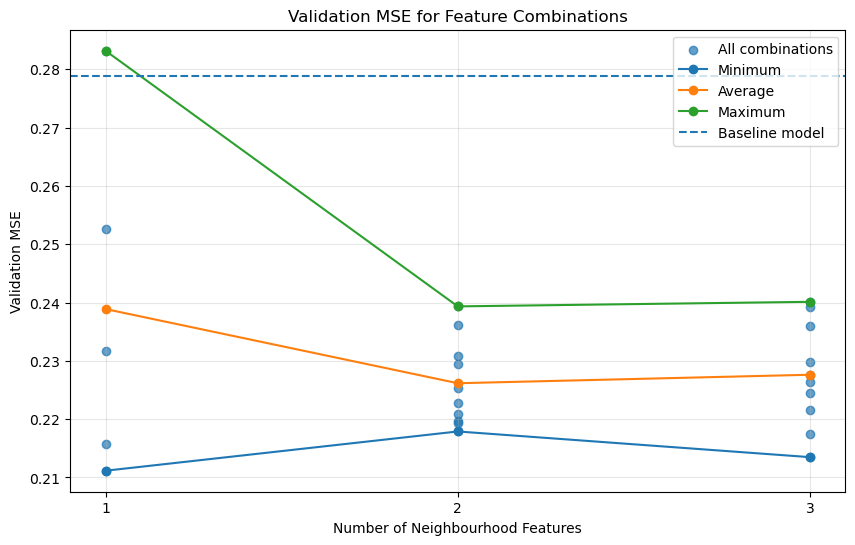

In [20]:
# ============================================================
# Plot: Validation MSE vs Number of Neighbourhood Features
#
# 图：验证集 MSE 与 neighbourhood 特征数量之间的关系
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# 1) Compute summary statistics for each feature count
#    (minimum, average, and maximum validation MSE)
#
# 1）计算每个特征数量对应的统计量
#    （最小值、平均值、最大值）
# ------------------------------------------------------------
summary_df = (
    all_combo_results_df
    .groupby("num_features")["val_mse"]   # Group by number of features / 按特征数量分组
    .agg(["min", "mean", "max"])          # Compute min / mean / max / 计算最小、平均、最大
    .reset_index()                       # Reset index for plotting / 重置索引方便绘图
)


# ------------------------------------------------------------
# 2) Compute baseline validation MSE
#
# 2）计算 baseline 模型在验证集上的 MSE
# ------------------------------------------------------------
baseline_val_mse = mean_squared_error(y_val, val_pred)


# ------------------------------------------------------------
# 3) Plot scatter points for all feature combinations
#
# 3）绘制所有特征组合的散点图
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

# Set random seed to make jitter reproducible
# 设置随机种子，使点的位置可复现
np.random.seed(26)

plt.scatter(
    all_combo_results_df["num_features"],   # x-axis: number of features / x轴：特征数量
    all_combo_results_df["val_mse"],        # y-axis: validation MSE / y轴：验证误差
    alpha=0.7,
    label="All combinations"
)


# ------------------------------------------------------------
# 4) Plot trend lines
#    Show min / average / max performance
#
# 4）绘制趋势线
#    展示最小 / 平均 / 最大验证误差
# ------------------------------------------------------------
plt.plot(
    summary_df["num_features"],
    summary_df["min"],
    marker="o",
    label="Minimum"
)

plt.plot(
    summary_df["num_features"],
    summary_df["mean"],
    marker="o",
    label="Average"
)

plt.plot(
    summary_df["num_features"],
    summary_df["max"],
    marker="o",
    label="Maximum"
)


# ------------------------------------------------------------
# 5) Plot baseline reference line
#
# 5）绘制 baseline 模型参考线
# ------------------------------------------------------------
plt.axhline(
    y=baseline_val_mse,
    linestyle="--",
    label="Baseline model"
)


# ------------------------------------------------------------
# 6) Figure formatting
#
# 6）图形格式设置
# ------------------------------------------------------------
plt.xlabel("Number of Neighbourhood Features")   # x轴标签
plt.ylabel("Validation MSE")                     # y轴标签
plt.title("Validation MSE for Feature Combinations")  # 图标题

# Show all tested feature counts on x-axis
# 在 x 轴显示所有测试过的特征数量
plt.xticks(sorted(all_combo_results_df["num_features"].unique()))

plt.legend()                 # 显示图例
plt.grid(True, alpha=0.3)    # 添加网格提高可读性

plt.show()

In [25]:
# ============================================================
# Generate results_k_feature_df for Figure 2 (Validation MSE)
# All 2-feature combinations
# ============================================================

from sklearn.neighbors import NearestNeighbors
from itertools import combinations

k_values = [3, 5, 7, 10, 11, 12, 15]

def compute_features_for_k(K):
    knn = NearestNeighbors(n_neighbors=K+1)
    knn.fit(X_train_raw[['Latitude', 'Longitude']])

    def neighbour_mean_price_local(query_df, y_train_series, exclude_self=False):
        y_train_series = y_train_series.loc[X_train_raw.index]
        _, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

        neigh_mean = []
        for row_i, idxs in enumerate(inds):
            if exclude_self:
                idxs = idxs[idxs != row_i]
                idxs = idxs[:K]
            else:
                idxs = idxs[:K]
            neigh_mean.append(y_train_series.iloc[idxs].mean())
        return np.array(neigh_mean)

    # Mean
    neigh_price_train_k = neighbour_mean_price_local(X_train_raw, y_train, exclude_self=True)
    neigh_price_val_k   = neighbour_mean_price_local(X_val_raw, y_train, exclude_self=False)
    neigh_price_test_k  = neighbour_mean_price_local(X_test_raw, y_train, exclude_self=False)

    # train neighbours
    knn_train_extra = NearestNeighbors(n_neighbors=K+1)
    knn_train_extra.fit(X_train_raw[['Latitude', 'Longitude']])

    _, idx_train_extra = knn_train_extra.kneighbors(X_train_raw[['Latitude', 'Longitude']])
    idx_train_k = idx_train_extra[:, 1:]

    # val/test neighbours
    _, idx_val = knn.kneighbors(X_val_raw[['Latitude', 'Longitude']])
    _, idx_test = knn.kneighbors(X_test_raw[['Latitude', 'Longitude']])

    # Median
    neigh_price_median_train_k = np.median(y_train.values[idx_train_k], axis=1)
    neigh_price_median_val_k   = np.median(y_train.values[idx_val[:, :K]], axis=1)
    neigh_price_median_test_k  = np.median(y_train.values[idx_test[:, :K]], axis=1)

    # Min
    neigh_price_min_train_k = y_train.values[idx_train_k].min(axis=1)
    neigh_price_min_val_k   = y_train.values[idx_val[:, :K]].min(axis=1)
    neigh_price_min_test_k  = y_train.values[idx_test[:, :K]].min(axis=1)

    # Max
    neigh_price_max_train_k = y_train.values[idx_train_k].max(axis=1)
    neigh_price_max_val_k   = y_train.values[idx_val[:, :K]].max(axis=1)
    neigh_price_max_test_k  = y_train.values[idx_test[:, :K]].max(axis=1)

    # Range
    neigh_price_range_train_k = neigh_price_max_train_k - neigh_price_min_train_k
    neigh_price_range_val_k   = neigh_price_max_val_k - neigh_price_min_val_k
    neigh_price_range_test_k  = neigh_price_max_test_k - neigh_price_min_test_k

    return {
        "Mean":   (neigh_price_train_k, neigh_price_val_k, neigh_price_test_k),
        "Median": (neigh_price_median_train_k, neigh_price_median_val_k, neigh_price_median_test_k),
        "Min":    (neigh_price_min_train_k, neigh_price_min_val_k, neigh_price_min_test_k),
        "Max":    (neigh_price_max_train_k, neigh_price_max_val_k, neigh_price_max_test_k),
        "Range":  (neigh_price_range_train_k, neigh_price_range_val_k, neigh_price_range_test_k),
    }

def run_two_features(feature_names, f_train_dict, f_val_dict, f_test_dict):
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()
    Xte = X_test_raw.copy()

    for name in feature_names:
        Xtr[name] = f_train_dict[name]
        Xva[name] = f_val_dict[name]
        Xte[name] = f_test_dict[name]

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)
    Xte_s = sc.transform(Xte)

    model_tmp = MLPRegressor(
        hidden_layer_sizes=(128, 32),
        activation='tanh',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=800,
        early_stopping=False,
        random_state=26
    )

    model_tmp.fit(Xtr_s, y_train)
    val_pred_tmp = model_tmp.predict(Xva_s)

    return mean_squared_error(y_val, val_pred_tmp)

results_k_feature = []

for K in k_values:
    feature_data = compute_features_for_k(K)
    feature_names = list(feature_data.keys())

    for combo in combinations(feature_names, 2):
        f_train_dict = {name: feature_data[name][0] for name in combo}
        f_val_dict   = {name: feature_data[name][1] for name in combo}
        f_test_dict  = {name: feature_data[name][2] for name in combo}

        val_mse = run_two_features(combo, f_train_dict, f_val_dict, f_test_dict)

        results_k_feature.append({
            "k": K,
            "combo": " + ".join(combo),
            "val_mse": val_mse
        })

results_k_feature_df = pd.DataFrame(results_k_feature)

In [1]:
# ============================================================
# Figure 2: Validation MSE vs Number of Neighbours (k)
# All 2-feature combinations
#
# 图 2：验证集 MSE 与邻居数量 k 的关系
# 所有两特征组合的结果
# ============================================================

# Create a new figure for plotting
# 创建新的绘图窗口
plt.figure(figsize=(10, 6))


# ------------------------------------------------------------
# Plot validation MSE curves for each feature combination
#
# 为每一个特征组合绘制验证误差曲线
# ------------------------------------------------------------
for combo_name in results_k_feature_df["combo"].unique():

    # Select rows corresponding to the current feature combination
    # 选出当前特征组合对应的数据
    subset = results_k_feature_df[
        results_k_feature_df["combo"] == combo_name].sort_values("k")   # sort by k so the line plot is ordered
                         # 按 k 排序，使折线图顺序正确

    # Plot validation MSE as a function of k
    # 绘制验证误差随 k 变化的曲线
    plt.plot(
        subset["k"],        # x-axis: number of neighbours
                            # x轴：邻居数量 k
        subset["val_mse"],  # y-axis: validation MSE
                            # y轴：验证集均方误差
        marker="o",
        label=combo_name
    )


# ------------------------------------------------------------
# Plot baseline model performance as a reference line
#
# 绘制 baseline 模型作为参考线
# ------------------------------------------------------------
baseline_val_mse = mean_squared_error(y_val, model.predict(X_val))

plt.axhline(
    y=baseline_val_mse,
    linestyle="--",
    label="Baseline model"
)


# ------------------------------------------------------------
# Figure formatting
#
# 图形格式设置
# ------------------------------------------------------------

# Axis labels
# 坐标轴标签
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Validation MSE")

# Figure title
# 图标题
plt.title("Validation MSE vs Number of Neighbours (Two-Feature Combinations)")

# Ensure all tested k values appear on the x-axis
# 保证 x 轴显示所有测试过的 k 值
plt.xticks(sorted(results_k_feature_df["k"].unique()))

# Place legend outside the plot to avoid overlapping
# 将图例放在图外侧，避免遮挡曲线
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Add grid for readability
# 添加网格提高可读性
plt.grid(True, alpha=0.3)

# Display the figure
# 显示图形
plt.show()

NameError: name 'plt' is not defined

In [28]:
# ============================================================
# 1) Combine original train and validation sets
#    合并原来的训练集和验证集
# ============================================================
X_train_final_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

# Make sure indices align
# 保证索引一致
X_train_final_raw = X_train_final_raw.sort_index()
y_train_final = y_train_final.loc[X_train_final_raw.index]

# ============================================================
# 2) Fit kNN on the new final training set
#    在新的最终训练集上建立 kNN
# ============================================================
best_K = 10
knn_final = NearestNeighbors(n_neighbors=best_K + 1)
knn_final.fit(X_train_final_raw[['Latitude', 'Longitude']])

y_train_final_aligned = y_train_final.to_numpy()

# ============================================================
# 3) Define function to compute neighbourhood summary features
#    定义函数：计算 neighbourhood 特征
# ============================================================
def neighbour_summary_feature_final(query_df, summary="mean", exclude_self=False):
    _, inds = knn_final.kneighbors(query_df[['Latitude', 'Longitude']])
    values = []

    for row_i, idxs in enumerate(inds):
        if exclude_self:
            idxs = idxs[idxs != row_i]
            idxs = idxs[:best_K]
        else:
            idxs = idxs[:best_K]

        neigh_prices = y_train_final_aligned[idxs]

        if summary == "mean":
            values.append(np.mean(neigh_prices))
        elif summary == "median":
            values.append(np.median(neigh_prices))
        elif summary == "min":
            values.append(np.min(neigh_prices))
        elif summary == "max":
            values.append(np.max(neigh_prices))
        elif summary == "range":
            values.append(np.max(neigh_prices) - np.min(neigh_prices))
        else:
            raise ValueError("summary must be one of: mean, median, min, max, range")

    return np.array(values)

# ============================================================
# 4) Compute only the selected best features
#    只计算最终选中的最佳 neighbourhood 特征
# ============================================================
feature_map = {
    "Mean": "mean",
    "Median": "median",
    "Min": "min",
    "Max": "max",
    "Range": "range"
}

best_features = ["Mean", "Median"]   # 改成你最终选出来的组合

train_final_feature_values = {}
test_feature_values = {}

for feat in best_features:
    summary_name = feature_map[feat]
    train_final_feature_values[feat] = neighbour_summary_feature_final(
        X_train_final_raw, summary=summary_name, exclude_self=True
    )
    test_feature_values[feat] = neighbour_summary_feature_final(
        X_test_raw, summary=summary_name, exclude_self=False
    )

# ============================================================
# 5) Final baseline model
#    最终 baseline 模型（用 train+val 重训）
# ============================================================
scaler_base_final = StandardScaler()

X_train_base_final = pd.DataFrame(
    scaler_base_final.fit_transform(X_train_final_raw),
    columns=X_train_final_raw.columns,
    index=X_train_final_raw.index
)

X_test_base_final = pd.DataFrame(
    scaler_base_final.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index
)

model_base_final = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

model_base_final.fit(X_train_base_final, y_train_final)
test_pred_base_final = model_base_final.predict(X_test_base_final)
baseline_test_mse_final = mean_squared_error(y_test, test_pred_base_final)

# ============================================================
# 6) Final enhanced model
#    最终增强模型（加入选中的 neighbourhood features）
# ============================================================
X_train_enh_final_raw = X_train_final_raw.copy()
X_test_enh_final_raw = X_test_raw.copy()

for feat in best_features:
    col_name = f"NeighbourPrice{feat}"
    X_train_enh_final_raw[col_name] = train_final_feature_values[feat]
    X_test_enh_final_raw[col_name] = test_feature_values[feat]

scaler_enh_final = StandardScaler()

X_train_enh_final = pd.DataFrame(
    scaler_enh_final.fit_transform(X_train_enh_final_raw),
    columns=X_train_enh_final_raw.columns,
    index=X_train_enh_final_raw.index
)

X_test_enh_final = pd.DataFrame(
    scaler_enh_final.transform(X_test_enh_final_raw),
    columns=X_test_enh_final_raw.columns,
    index=X_test_enh_final_raw.index
)

model_enh_final = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

model_enh_final.fit(X_train_enh_final, y_train_final)
test_pred_enh_final = model_enh_final.predict(X_test_enh_final)
enhanced_test_mse_final = mean_squared_error(y_test, test_pred_enh_final)

# ============================================================
# 7) Final comparison
#    最终比较
# ============================================================
print("Final Baseline Test MSE:", baseline_test_mse_final)
print("Final Enhanced Test MSE:", enhanced_test_mse_final)
print("Delta Test MSE (Enhanced - Baseline):", enhanced_test_mse_final - baseline_test_mse_final)

Final Baseline Test MSE: 0.24851459335241777
Final Enhanced Test MSE: 0.17612367909916343
Delta Test MSE (Enhanced - Baseline): -0.07239091425325433
